### YDL 2026 · Неделя 2 · День 1 · разбор на футбольных данных

Перед нами `players_analysis.csv` — **настоящие** данные Transfermarkt: ~28 700 футболистов, по каждому собрана карьера (матчи, голы, ассисты, минуты) и приклеена рыночная стоимость, возраст, рост, позиция и число игр за сборную.

In [1]:
import pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv('players_analysis.csv')
print('строк:', len(df), '  колонок:', df.shape[1])
df.head()

строк: 28739   колонок: 14


,name,position,sub_position,foot,country,age,height_cm,caps,matches,goals,assists,minutes,goals_per90,market_value_eur
0,Miroslav Klose,Attack,Centre-Forward,right,Germany,46.0,184.0,NaN,136,48,25,8808,0.490,1000000.0
1,Roman Weidenfeller,Goalkeeper,Goalkeeper,left,Germany,43.8,190.0,NaN,152,0,0,13508,0.000,750000.0
2,Dimitar Berbatov,Attack,Centre-Forward,NaN,Bulgaria,43.3,NaN,NaN,122,38,13,8788,0.389,1000000.0
3,Lúcio,Defender,Centre-Back,NaN,Brazil,46.1,NaN,NaN,4,0,0,307,0.000,200000.0
4,Tom Starke,Goalkeeper,Goalkeeper,right,Germany,43.2,194.0,NaN,12,0,0,1080,0.000,100000.0


In [2]:
df['position'].value_counts()

position
Defender      9190
Attack        8568
Midfield      8545
Goalkeeper    2349
Missing         86
Name: count, dtype: int64

## Задание 1. Стоимость игрока

Считаем сводку по `market_value_eur`. Не глядим на неё как на формальность — сравниваем среднее и медиану.

In [3]:
df['market_value_eur'].describe().round(0)

count        25827.0
mean       1928274.0
std        7033055.0
min          10000.0
25%         150000.0
50%         300000.0
75%         850000.0
max      200000000.0
Name: market_value_eur, dtype: float64

In [4]:
print('среднее :', round(df.market_value_eur.mean()))
print('медиана :', round(df.market_value_eur.median()))
print('отношение среднее/медиана:', round(df.market_value_eur.mean()/df.market_value_eur.median(), 2))

среднее : 1928274
медиана : 300000
отношение среднее/медиана: 6.43


### Ловушка №1: среднее завышено перекосом

Среднее (около 1.9 млн €) в **6.4 раза** больше медианы (около 0.3 млн €). Когда они так расходятся, данные сильно перекошены, и среднее уже не «типичный игрок». Посмотрим на гистограмму и на тех, кто тянет хвост.

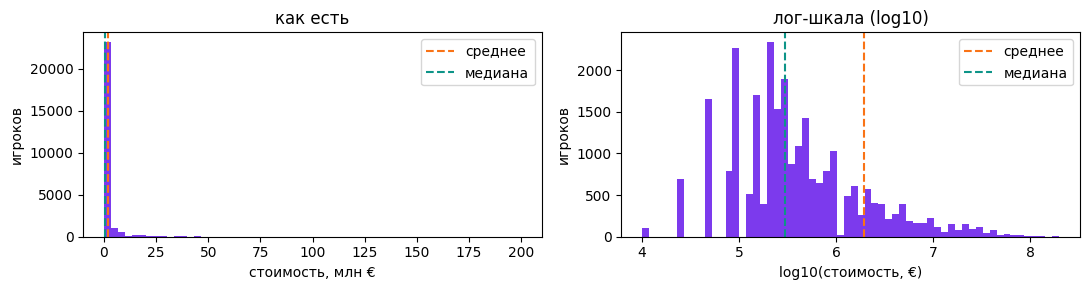

In [5]:
v = df.market_value_eur.dropna() / 1e6
fig, ax = plt.subplots(1, 2, figsize=(11, 3))

# слева: как есть — длинный хвост всё прижимает к левому краю
ax[0].hist(v, bins=60, color='#7C3AED')
ax[0].axvline(v.mean(), color='#F97316', linestyle='--', label='среднее')
ax[0].axvline(v.median(), color='#0D9488', linestyle='--', label='медиана')
ax[0].set_xlabel('стоимость, млн €'); ax[0].set_ylabel('игроков')
ax[0].set_title('как есть'); ax[0].legend()

# справа: та же стоимость в log10 — виден настоящий перекос
lv = np.log10(df.market_value_eur.dropna())
ax[1].hist(lv, bins=60, color='#7C3AED')
ax[1].axvline(np.log10(df.market_value_eur.mean()), color='#F97316', linestyle='--', label='среднее')
ax[1].axvline(np.log10(df.market_value_eur.median()), color='#0D9488', linestyle='--', label='медиана')
ax[1].set_xlabel('log10(стоимость, €)'); ax[1].set_ylabel('игроков')
ax[1].set_title('лог-шкала (log10)'); ax[1].legend()

plt.tight_layout(); plt.show()

In [6]:
df.nlargest(10, 'market_value_eur')[['name','position','goals','market_value_eur']]

,name,position,goals,market_value_eur
18979,Erling Haaland,Attack,255,200000000.0
16662,Kylian Mbappé,Attack,326,180000000.0
17653,Vinicius Junior,Attack,120,180000000.0
22390,Jude Bellingham,Midfield,70,160000000.0
18711,Phil Foden,Midfield,105,150000000.0
19342,Bukayo Saka,Attack,80,130000000.0
22075,Michael Olise,Attack,58,130000000.0
22355,Jamal Musiala,Midfield,69,130000000.0
16964,Alexander Isak,Attack,123,120000000.0
17265,Declan Rice,Midfield,34,120000000.0


In [7]:
# то же через группировку: где сидит дорогой хвост
df.groupby('position')['market_value_eur'].agg(['count','mean','median']).round(0)

,count,mean,median
position,,,
Attack,7599,2184301.0,300000.0
Defender,8303,1791860.0,300000.0
Goalkeeper,2188,1120288.0,250000.0
Midfield,7674,2067340.0,300000.0
Missing,63,146825.0,100000.0


Хвост — это десяток суперзвёзд-нападающих (Холанд, Мбаппе, Винисиус) со стоимостью в сотни миллионов. Их единицы на 25 тысяч, но они утягивают среднее вверх. Честный ответ про «типичного футболиста» даёт **медиана** (около 0.3 млн €), а не среднее.

## Ловушка №2: пропуски, которые молчат

Среднюю стоимость мы посчитали. Но сначала спросим: по скольким игрокам она вообще считается — и кто молчит?

In [8]:
print('всего игроков :', len(df))
print('есть цена     :', df.market_value_eur.notna().sum(), '   не известны:', df.market_value_eur.isna().sum())

всего игроков : 28739
есть цена     : 25827    не известны: 2912


In [9]:
# кто именно без цены? сравним их карьеру с теми, у кого цена есть
df.groupby(df.market_value_eur.isna())[['matches','goals']].median()\
  .rename({False:'есть цена', True:'нет цены'})

,matches,goals
market_value_eur,,
есть цена,36.0,1.0
нет цены,5.0,0.0


## z-score

Стандартизуем стоимость и вытащим точки, где значение далеко от среднего (|z| > 3).

In [86]:
z = (df.market_value_eur - df.market_value_eur.mean()) / df.market_value_eur.std()
df.assign(z=z.round(1)).loc[z > 3, ['name','position','goals','market_value_eur','z']]\
  .sort_values('z', ascending=False)

,name,position,goals,market_value_eur,z
18979,Erling Haaland,Attack,255,"200,000,000.00",28.20
17653,Vinicius Junior,Attack,120,"180,000,000.00",25.30
16662,Kylian Mbappé,Attack,326,"180,000,000.00",25.30
22390,Jude Bellingham,Midfield,70,"160,000,000.00",22.50
18711,Phil Foden,Midfield,105,"150,000,000.00",21.10
...,...,...,...,...,...
25647,Conrad Harder,Attack,16,"24,000,000.00",3.10
17549,Arthur Theate,Defender,13,"24,000,000.00",3.10
25547,Luiz Henrique,Attack,12,"24,000,000.00",3.10
14287,Allan Saint-Maximin,Attack,35,"24,000,000.00",3.10


Все выбросы — топ-нападающие и атакующие полузащитники (Холанд на `z ≈ 28`). Те же звёзды, что портили среднюю в Задании 1, — z-score нашёл их автоматически. Оговорка: `z ≈ 28` при нормальном законе невозможен в принципе, так что это сигнал не «игрок аномален на 28 сигм», а «данные не нормальные», и порог 2–3σ здесь условный.

## Задание 2. Голы и стоимость игрока

Выберем две величины — число голов за карьеру и рыночную стоимость — и посчитаем Pearson r. Вопрос задания: связь настоящая или совпадение? И сразу помним: корреляция — это ещё не причинность.

In [11]:
r  = df['goals'].corr(df['market_value_eur'])
rs = df['goals'].corr(df['market_value_eur'], method='spearman')
print('Pearson r  :', round(r, 2))
print('Spearman r :', round(rs, 2))

Pearson r  : 0.31
Spearman r : 0.39


### Связь настоящая или совпадение?

`r ≈ 0.31` — заметный плюс: больше голов, выше цена. Но Pearson легко ломается о выбросы (те самые суперзвёзды). Проверим робастно: разобьём игроков по числу голов и посмотрим **медианную** стоимость каждой группы — медиана выбросов не боится. Если связь настоящая, медианы должны расти.

In [12]:
df['goal_bucket'] = pd.cut(df['goals'], [-1, 0, 4, 19, 49, 99, 9999],
                           labels=['0', '1-4', '5-19', '20-49', '50-99', '100+'])
df.groupby('goal_bucket', observed=True)['market_value_eur'].agg(['size', 'median']).round(0)

,size,median
goal_bucket,,
0,12999,200000.0
1-4,8110,300000.0
5-19,5233,600000.0
20-49,1687,1000000.0
50-99,550,2500000.0
100+,160,5000000.0


In [13]:
# разрежем по позиции — здесь, в отличие от роста, знак НЕ переворачивается
df.groupby('position')[['goals', 'market_value_eur']]\
  .apply(lambda g: round(g.goals.corr(g.market_value_eur), 2)).rename('r внутри позиции')

position
Attack        0.38
Defender      0.32
Goalkeeper    0.06
Midfield      0.32
Missing       0.51
Name: r внутри позиции, dtype: float64

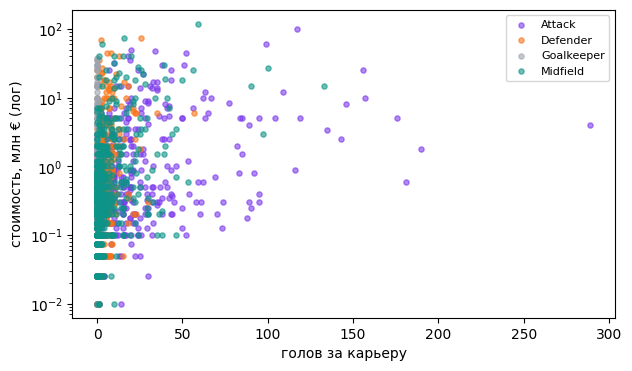

In [14]:
# покажем глазами: больше голов — дороже (ось цены логарифмическая, иначе суперзвёзды всё сплющат)
colors = {'Attack':'#7C3AED','Midfield':'#0D9488','Defender':'#F97316','Goalkeeper':'#9CA3AF'}
fig, ax = plt.subplots(figsize=(7,4))
for pos, g in df.dropna(subset=['market_value_eur']).groupby('position'):
    if pos not in colors: continue
    s = g.sample(min(len(g), 700), random_state=1)
    ax.scatter(s.goals, s.market_value_eur/1e6, s=14, color=colors[pos], label=pos, alpha=0.6)
ax.set_yscale('log')
ax.set_xlabel('голов за карьеру'); ax.set_ylabel('стоимость, млн € (лог)'); ax.legend(fontsize=8)
plt.show()

### Ловушка №3: корреляция ≠ причинность

Связь **настоящая, а не совпадение**: медианная цена монотонно растёт от 0.2 млн € (ноль голов) до 5 млн € (100+ голов), Spearman ≈ 0.39, и внутри каждой позиции знак тот же. Но из этого **не следует**, что голы *делают* игрока дорогим:

- **Это во многом объём, а не мастерство.** Сырое число голов копится с минутами. Голы *за 90 минут* коррелируют со стоимостью уже слабо (`r ≈ 0.17` против `0.31`): дорожает «много играл на высоком уровне», а не «бьёт точнее».
- **Позиция решает.** Вратари и защитники дорогие почти без голов — в корзине «0 голов» медиана уже 0.2 млн €. Голы — лишь один из путей к цене, в основном для нападающих.
- **Общая причина сверху.** И голы, и цена растут из одного: талант, уровень лиги, минуты, хайп. Корреляция ловит это эхо, а не причинно-следственную стрелку.

Вердикт: связь реальна, но читать её как «забивай — и подорожаешь» нельзя.

### Дополнительно: возраст и стоимость

Обе величины числовые — берём Pearson r и проверяем по медиане в разрезе возраста.

In [15]:
ra = df['age'].corr(df['market_value_eur'])
print('возраст vs стоимость, Pearson r =', round(ra, 2))
df.groupby('position')[['age', 'market_value_eur']]\
  .apply(lambda g: round(g.age.corr(g.market_value_eur), 2)).rename('r внутри позиции')

возраст vs стоимость, Pearson r = -0.2


position
Attack       -0.18
Defender     -0.23
Goalkeeper   -0.19
Midfield     -0.20
Missing       0.36
Name: r внутри позиции, dtype: float64

In [16]:
df['age_bucket'] = pd.cut(df['age'], [15, 21, 25, 29, 33, 45],
                          labels=['<=21', '22-25', '26-29', '30-33', '34+'])
df.groupby('age_bucket', observed=True)['market_value_eur'].agg(['size', 'median']).round(0)

,size,median
age_bucket,,
<=21,3312,500000.0
22-25,5233,600000.0
26-29,5822,500000.0
30-33,5634,300000.0
34+,8335,200000.0


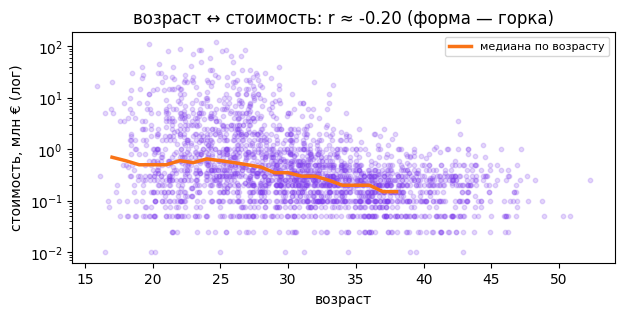

In [17]:
# график: возраст ↔ стоимость
dfv = df.dropna(subset=['market_value_eur', 'age'])
med = (dfv.groupby(dfv.age.round())['market_value_eur'].median() / 1e6)
med = med[(med.index >= 17) & (med.index <= 38)]
s = dfv.sample(2500, random_state=1)
fig, ax = plt.subplots(figsize=(7,3))
ax.scatter(s.age, s.market_value_eur/1e6, s=10, color='#7C3AED', alpha=0.2)
ax.plot(med.index, med.values, color='#F97316', lw=2.5, label='медиана по возрасту')
ax.set_yscale('log')
ax.set_xlabel('возраст'); ax.set_ylabel('стоимость, млн € (лог)')
ax.set_title('возраст ↔ стоимость: r ≈ -0.20 (форма — горка)'); ax.legend(fontsize=8)
plt.show()

`r ≈ -0.20`: старше — дешевле, и знак держится **внутри каждой позиции** (от -0.18 до -0.23), так что это не Симпсон, а ровная связь. Но линейный r сглаживает главное: по медиане видно **горку** — стоимость растёт к пику в 22–25 лет (около 0.6 млн €) и потом падает до 0.2 млн € к 34+. Связь реальна и почти причинна (меньше лет карьеры впереди — ниже цена), но её форма — не прямая, а парабола, и один Pearson r это прячет.

### Дополнительно: минуты на поле и голы

Обе величины числовые — берём Pearson r и проверяем по медиане в разрезе наигранных минут.

In [18]:
r  = df['minutes'].corr(df['goals'])
rs = df['minutes'].corr(df['goals'], method='spearman')
print('минуты vs голы, Pearson r  =', round(r, 2))
print('минуты vs голы, Spearman r =', round(rs, 2))
df.groupby('position')[['minutes', 'goals']]\
  .apply(lambda g: round(g.minutes.corr(g.goals), 2)).rename('r внутри позиции')

минуты vs голы, Pearson r  = 0.58
минуты vs голы, Spearman r = 0.72


position
Attack        0.89
Defender      0.78
Goalkeeper    0.12
Midfield      0.77
Missing       0.77
Name: r внутри позиции, dtype: float64

In [19]:
# (восстановлено) медиана голов по корзинам минут
df['min_bucket'] = pd.qcut(df['minutes'], 5,
                           labels=['оч.мало', 'мало', 'средне', 'много', 'оч.много'])
df.groupby('min_bucket', observed=True).agg(минут_медиана=('minutes', 'median'),
                                            голов_медиана=('goals', 'median'),
                                            игроков=('goals', 'size'))

,минут_медиана,голов_медиана,игроков
min_bucket,,,
оч.мало,61.0,0.0,5855
мало,448.0,0.0,5643
средне,1722.0,1.0,5748
много,4770.0,3.0,5745
оч.много,13108.0,11.0,5748


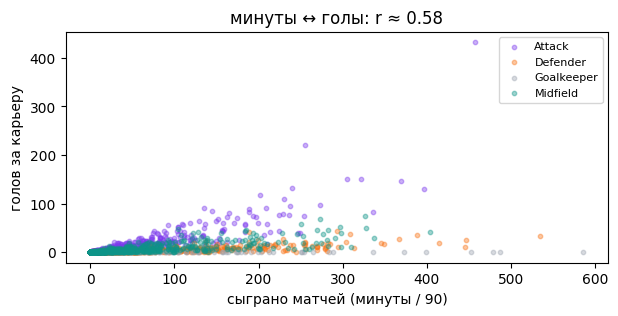

In [20]:
# график: минуты ↔ голы
colors = {'Attack':'#7C3AED','Midfield':'#0D9488','Defender':'#F97316','Goalkeeper':'#9CA3AF'}
s = df.sample(2500, random_state=1)
fig, ax = plt.subplots(figsize=(7,3))
for pos, g in s.groupby('position'):
    if pos not in colors: continue
    ax.scatter(g.minutes/90, g.goals, s=10, color=colors[pos], alpha=0.4, label=pos)
ax.set_xlabel('сыграно матчей (минуты / 90)'); ax.set_ylabel('голов за карьеру')
ax.set_title('минуты ↔ голы: r ≈ 0.58'); ax.legend(fontsize=8)
plt.show()

In [21]:
# а растёт ли РЕЗУЛЬТАТИВНОСТЬ (голы за 90) с минутами? проверим на тех, кто реально играл
pl = df[df.minutes >= 900]
print('минуты vs голы/90, r =', round(pl['minutes'].corr(pl['goals_per90']), 2))

минуты vs голы/90, r = 0.06


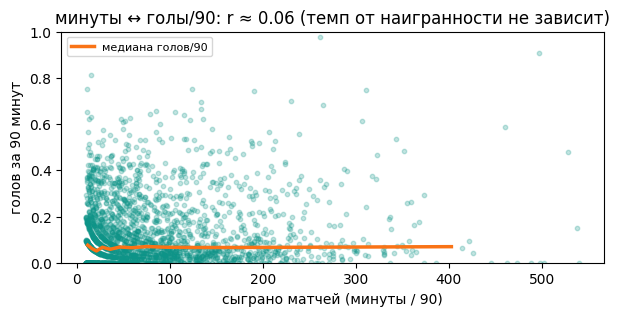

In [22]:
# график: минуты ↔ голы за 90 — связи почти нет (r ≈ 0.06)
pl = df[df.minutes >= 900]
s = pl.sample(min(len(pl), 2500), random_state=1)
fig, ax = plt.subplots(figsize=(7,3))
ax.scatter(s.minutes/90, s.goals_per90, s=10, color='#0D9488', alpha=0.25)
# медиана голов/90 по корзинам минут — линия почти плоская
binned = pl.groupby(pd.qcut(pl.minutes, 12, duplicates='drop'), observed=True)['goals_per90'].median()
xs = [iv.mid/90 for iv in binned.index]
ax.plot(xs, binned.values, color='#F97316', lw=2.5, label='медиана голов/90')
ax.set_xlabel('сыграно матчей (минуты / 90)'); ax.set_ylabel('голов за 90 минут')
ax.set_title('минуты ↔ голы/90: r ≈ 0.06 (темп от наигранности не зависит)')
ax.set_ylim(0, 1.0); ax.legend(fontsize=8)
plt.show()

Но это почти **тавтология, а не открытие**: больше минут — больше моментов забить, чисто механически. Проверка добивает: результативность *за 90 минут* с минутами почти не связана (`r ≈ 0.06`) — наигранное время не делает игрока точнее, оно лишь даёт ему больше попыток. Вот наглядная разница **объёма и мастерства** — и ровно поэтому сырое число голов (и связь «голы → цена» из Задания 2) во многом про наигранные минуты, а не про уровень удара.

## Задание 8. t-тест и p-value: связь значима или велика?

Возьмём самую сильную связь разбора — **минуты и голы** — и спросим не «есть ли связь», а «можно ли верить ей как открытию». Посчитаем p-value корреляции, затем t-тест между группами, и поймаем главную ловушку больших данных: при большом N «значимо» достаётся почти даром.

In [23]:
from scipy import stats

s = df[['minutes', 'goals']].dropna()
r, p = stats.pearsonr(s.minutes, s.goals)
print('N       =', len(s))
print('r       =', round(r, 2), '  (r^2 =', round(r**2, 2), '-> объясняет ~34% разброса голов)')
print('p-value =', p)

N       = 28739
r       = 0.58   (r^2 = 0.34 -> объясняет ~34% разброса голов)
p-value = 0.0


`p-value = 0.0` — связь голов с минутами **точно не случайность**. Казалось бы, вопрос закрыт. Но крошечное p здесь — во многом заслуга огромного N, а не силы связи. Проверим, насколько дёшева тут «значимость».

In [24]:
from scipy.stats import t as tdist

n = len(s)
tc = tdist.ppf(0.975, n - 2)
rcrit = tc / np.sqrt(n - 2 + tc**2)
print(f'при N={n} порог значимости — это |r| всего {rcrit:.3f}')
print(f'то есть связь, объясняющая {rcrit**2*100:.2f}% разброса, уже «значима»')
print()
# заведомо слабая пара: голы за 90 минут vs минуты
pl = df[df.minutes >= 900][['minutes', 'goals_per90']].dropna()
rw, pw = stats.pearsonr(pl.minutes, pl.goals_per90)
print(f'голы/90 vs минуты: r={rw:.2f} (почти ноль, объясняет {rw**2*100:.1f}%), но p={pw:.0e} -> формально ЗНАЧИМО')

при N=28739 порог значимости — это |r| всего 0.012
то есть связь, объясняющая 0.01% разброса, уже «значима»



голы/90 vs минуты: r=0.06 (почти ноль, объясняет 0.4%), но p=5e-17 -> формально ЗНАЧИМО


Вот ловушка. Порог «значимости» при таком N — это `|r| ≈ 0.012`: связь, объясняющая жалкие **0.01%** разброса, уже пройдёт порог. И живой пример: голы *за 90 минут* и минуты связаны на `r ≈ 0.06` (объясняют 0.4% — практически ничего), но `p ≈ 5e-17` кричит «значимо!». При больших данных p-value почти всегда мизерный, так что сам факт `p < 0.05` не говорит **ничего** о важности связи.

In [25]:
# t-тест по сути задания: делим игроков по медиане минут и сравниваем голы
med = s.minutes.median()
hi = s[s.minutes > med].goals
lo = s[s.minutes <= med].goals
t, pt = stats.ttest_ind(hi, lo, equal_var=False)
d = (hi.mean() - lo.mean()) / np.sqrt((hi.std()**2 + lo.std()**2) / 2)
print('голы у «много минут» vs «мало минут»:')
print(f'  среднее : {hi.mean():.1f}  против  {lo.mean():.1f} гола')
print(f'  t = {t:.0f},   p = {pt:.0e}')
print(f'  размер эффекта Cohen d = {d:.2f}  (0.5 средний, 0.8 большой -> тут средне-крупный)')

голы у «много минут» vs «мало минут»:
  среднее : 12.0  против  0.6 гола
  t = 60,   p = 0e+00
  размер эффекта Cohen d = 0.71  (0.5 средний, 0.8 большой -> тут средне-крупный)


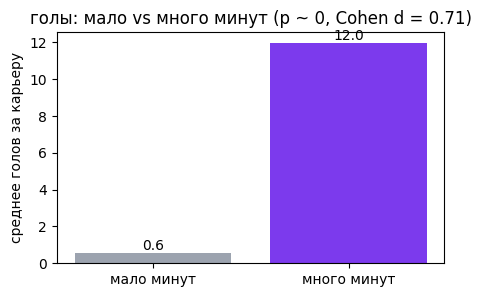

In [26]:
# глазами: тут эффект не только значим, но и ВЕЛИК
fig, ax = plt.subplots(figsize=(5,3))
ax.bar(['мало минут', 'много минут'], [lo.mean(), hi.mean()], color=['#9CA3AF', '#7C3AED'])
for i, v in enumerate([lo.mean(), hi.mean()]):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('среднее голов за карьеру')
ax.set_title('голы: мало vs много минут (p ~ 0, Cohen d = 0.71)')
plt.show()

Теперь смотрим на **размер**, а не на p. Средние `12.0` против `0.6` гола, Cohen d = 0.71 — связь не только значима, но и реально большая, и доказывают это разница средних и d, а **не** p-value.

**Итог Задания 8:** p-value отвечает только на вопрос «эффект не ноль?», а не «эффект большой?». При N в десятки тысяч p почти всегда крошечный, поэтому «звёздочки значимости» дёшевы. Доверять надо размеру эффекта (r², разнице средних, Cohen d), а не самому факту `p < 0.05`.

## Ловушка №4: смещение выборки

Представим, что о стоимости футболистов мы судим по тем, кого показывают по ТВ — по игрокам сборных (`caps > 0`). Сравним их среднюю цену со средней по всем.

In [27]:
nt = df.caps.fillna(0) > 0
print('средняя цена по всем        :', round(df.market_value_eur.mean()))
print('средняя цена у сборников    :', round(df.loc[nt, 'market_value_eur'].mean()))
print('доля сборников в данных     :', str(round(100*nt.mean(), 1)) + '%')
print('завышение от такой выборки  :', str(round(100*(df.loc[nt,'market_value_eur'].mean()/df.market_value_eur.mean()-1))) + '%')

средняя цена по всем        : 1928274
средняя цена у сборников    : 5500156
доля сборников в данных     : 31.7%
завышение от такой выборки  : 185%


Игроки сборных стоят в среднем 5.5 млн € против 1.9 млн € по всем — выборка завышает цену на **185%**. Причина: в сборную берут лучших, и они же самые дорогие. Это «опрос выживших»: судить о «типичном футболисте» по тем, кто на виду, — кривая выборка, дающая кривой вывод.

## Что мы поймали

1. **Средняя стоимость** завышена горсткой суперзвёзд (среднее 1.9 млн € против медианы 0.3 млн €). Честный ответ даёт медиана.
2. **Средняя стоимость молча посчитана не по всем**: у 2 912 малозаметных игроков цены нет, и они выпали из картины.
3. **Корреляция голов и стоимости** настоящая (медиана цены монотонно растёт, Spearman 0.39), но это не причинность: сырые голы — во многом объём (голы/90 коррелируют слабее), а вратари дороги почти без голов.
4. **Выборка по сборникам** завысила стоимость на 185%, потому что в сборную берут лучших («опрос выживших»).
5. **«Значимая» корреляция** между случайными колонками оказалась призраком (p-hacking).

Пять чисел, и каждое звучало убедительно. Ни одному нельзя было верить без проверки. Формулы считает машина — за нами остаётся скепсис.